<a href="https://colab.research.google.com/github/Sneha-code01/ML/blob/main/battery_life_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Hawaii Natural Energy Institute examined 14 NMC-LCO 18650 batteries with a nominal capacity of 2.8 Ah, which were cycled over 1000 times at 25°C with a CC-CV charge rate of C/2 rate and discharge rate of 1.5C.

From that source dataset, I created features that showcase the voltage and current behaviour over each cycle. Those features can be used to predict the remaining useful life (RUL) of the batteries. The dataset contains the summary of the 14 batteries.


       Cycle_Index  Discharge Time (s)  Decrement 3.6-3.4V (s)  \
13060        122.0             2069.31                 728.000   
10828         43.0             2208.69                 722.407   
5596         209.0             2002.85                 678.400   
554          576.0             1595.38                 476.000   

       Max. Voltage Dischar. (V)  Min. Voltage Charg. (V)  Time at 4.15V (s)  \
13060                      3.993                    3.425           4658.344   
10828                      3.996                    3.419           4957.344   
5596                       3.983                    3.456           4430.321   
554                        3.914                    3.849           2834.375   

       Time constant current (s)  Charging time (s)   RUL  
13060                    5588.34            9068.52   992  
10828                    5944.31            9429.44  1065  
5596                     5372.32            9196.35   894  
554                      378

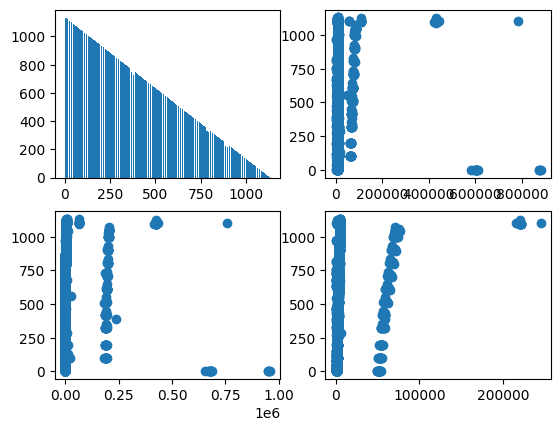

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Battery_RUL.csv")
print(df.sample(4))
print(df.isnull().sum())

fig, ax = plt.subplots(2, 2)
ax[0,0].bar(df['Cycle_Index'], df['RUL'])
ax[0,1].scatter(df['Charging time (s)'], df['RUL'])
ax[1,0].scatter(df['Discharge Time (s)'],df['RUL'])
ax[1,1].scatter(df['Time at 4.15V (s)'], df['RUL'])
plt.show()



In [ ]:
print(df.iloc[:,8])

0        1112
1        1111
2        1110
3        1109
4        1107
         ... 
15059       4
15060       3
15061       2
15062       1
15063       0
Name: RUL, Length: 15064, dtype: int64


In [33]:

X = df.iloc[:,0].values
X = X.reshape(-1,1)
X = np.hstack((np.ones((X.shape[0],1)), X))
Y = df.iloc[:,8].values

def model(X,Y,learning_rate, iteration):
  theta = np.zeros((2,1))
  m = Y.size

  for i in range(iteration):
   Y_pred = np.dot(X,theta)
   cost = (1/(2*m))*np.sum(np.square(Y - Y_pred))

   d_theta = (1/m)*np.dot(X.T,Y - Y_pred)
   theta = theta - learning_rate*d_theta

  return theta

In [36]:
itr = 150
lr = 0.000005

model(X,Y,learning_rate=lr,iteration=itr)
np.dot([1,500],theta)

array([[-1.96397797e+70, -1.96221180e+70, -1.96044563e+70, ...,
        -3.53233448e+67, -1.76616724e+67,  0.00000000e+00],
       [-1.45925666e+73, -1.45794438e+73, -1.45663210e+73, ...,
        -2.62456234e+70, -1.31228117e+70,  0.00000000e+00]])